In [ ]:
pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
bank_marketing = fetch_ucirepo(id=222)

# data (as pandas dataframes)
X = bank_marketing.data.features
y = bank_marketing.data.targets

# metadata
print(bank_marketing.metadata)

# variable information
print(bank_marketing.variables)



{'uci_id': 222, 'name': 'Bank Marketing', 'repository_url': 'https://archive.ics.uci.edu/dataset/222/bank+marketing', 'data_url': 'https://archive.ics.uci.edu/static/public/222/data.csv', 'abstract': 'The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution. The classification goal is to predict if the client will subscribe a term deposit (variable y).', 'area': 'Business', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 45211, 'num_features': 16, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Occupation', 'Marital Status', 'Education Level'], 'target_col': ['y'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2014, 'last_updated': 'Fri Aug 18 2023', 'dataset_doi': '10.24432/C5K306', 'creators': ['S. Moro', 'P. Rita', 'P. Cortez'], 'intro_paper': {'ID': 277, 'type': 'NATIVE', 'title': 'A data-driven approach to predict the s

Create Data Frame

In [ ]:
from ucimlrepo import fetch_ucirepo
import pandas as pd

# Load the Bank Marketing dataset
bank_marketing = fetch_ucirepo(id=222)

# Features
X = bank_marketing.data.features

# Target column
y = bank_marketing.data.targets

# Combine both into one DataFrame
df = pd.concat([X, y], axis=1)

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no


In [ ]:
print(df.shape)
df.info()

(45211, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          45211 non-null  int64 
 1   job          44923 non-null  object
 2   marital      45211 non-null  object
 3   education    43354 non-null  object
 4   default      45211 non-null  object
 5   balance      45211 non-null  int64 
 6   housing      45211 non-null  object
 7   loan         45211 non-null  object
 8   contact      32191 non-null  object
 9   day_of_week  45211 non-null  int64 
 10  month        45211 non-null  object
 11  duration     45211 non-null  int64 
 12  campaign     45211 non-null  int64 
 13  pdays        45211 non-null  int64 
 14  previous     45211 non-null  int64 
 15  poutcome     8252 non-null   object
 16  y            45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [ ]:
df.isnull().sum()

,0
age,0
job,288
marital,0
education,1857
default,0
balance,0
housing,0
loan,0
contact,13020
day_of_week,0


Replace missing categorical values with "Unknown"

In [ ]:
df["job"] = df["job"].fillna("Unknown")
df["education"] = df["education"].fillna("Unknown")
df["contact"] = df["contact"].fillna("Unknown")
df["poutcome"] = df["poutcome"].fillna("Unknown")

In [ ]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day_of_week,0


Create Column: Customer Status

In [ ]:
df["ConversionStatus"] = df["y"].map({
    "yes": "Converted",
    "no": "Not Converted"
})

Create Column: Age Group

In [ ]:
df["AgeGroup"] = pd.cut(
    df["age"],
    bins=[18,30,40,50,60,100],
    labels=[
        "18-30",
        "31-40",
        "41-50",
        "51-60",
        "60+"
    ]
)

In [ ]:
df.to_csv("bank_marketing_cleaned.csv", index=False)

In [ ]:
from google.colab import files
files.download("bank_marketing_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Total Customers Contacted
total_customers = len(df)

# Successful Conversions
converted_customers = len(df[df["y"] == "yes"])

# Unsuccessful Conversions
not_converted = len(df[df["y"] == "no"])

# Conversion Rate
conversion_rate = (converted_customers / total_customers) * 100

# Average Age
average_age = df["age"].mean()

print(f"Total Customers: {total_customers}")
print(f"Converted Customers: {converted_customers}")
print(f"Not Converted: {not_converted}")
print(f"Conversion Rate: {conversion_rate:.2f}%")
print(f"Average Customer Age: {average_age:.2f}")

Total Customers: 45211
Converted Customers: 5289
Not Converted: 39922
Conversion Rate: 11.70%
Average Customer Age: 40.94


Analysis 1: Conversion by Job

In [ ]:
job_conversion = (
    df.groupby(["job", "y"])
      .size()
      .unstack()
      .fillna(0)
)

job_conversion

y,no,yes
job,,
Unknown,254,34
admin.,4540,631
blue-collar,9024,708
entrepreneur,1364,123
housemaid,1131,109
management,8157,1301
retired,1748,516
self-employed,1392,187
services,3785,369


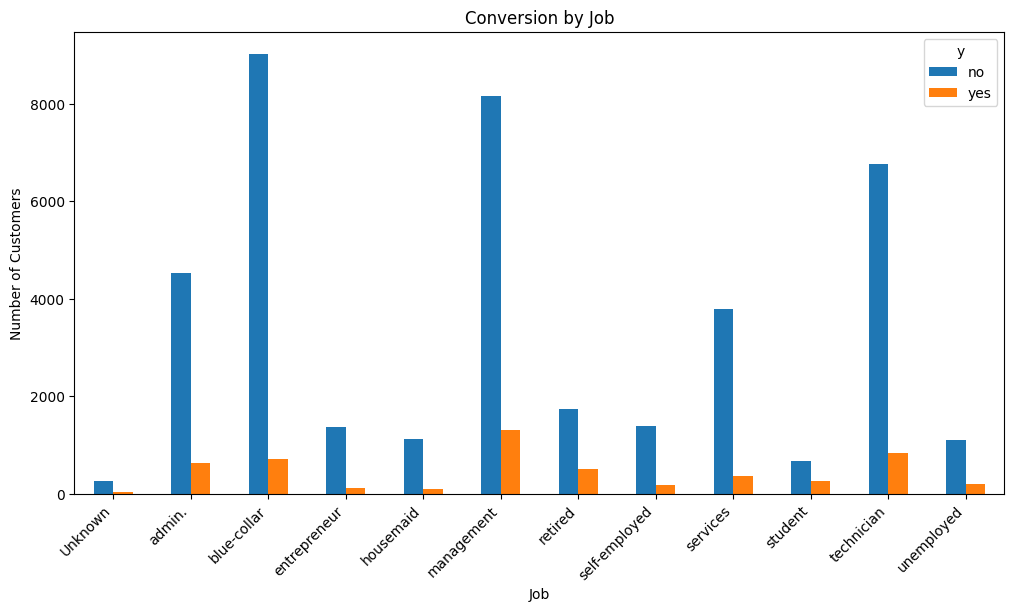

In [ ]:
import matplotlib.pyplot as plt

job_conversion.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Conversion by Job")
plt.xlabel("Job")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45, ha="right")

plt.show()

Conversion by Contact Method

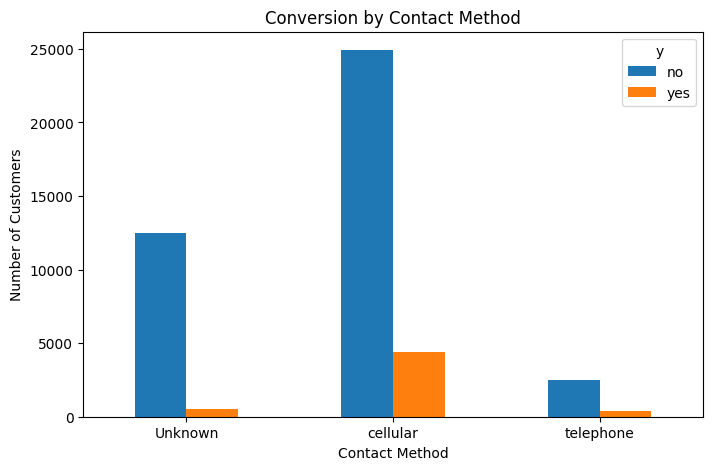

In [ ]:
contact_conversion = (
    df.groupby(["contact", "y"])
      .size()
      .unstack()
      .fillna(0)
)

contact_conversion.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Conversion by Contact Method")
plt.xlabel("Contact Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.show()

Conversion by Education

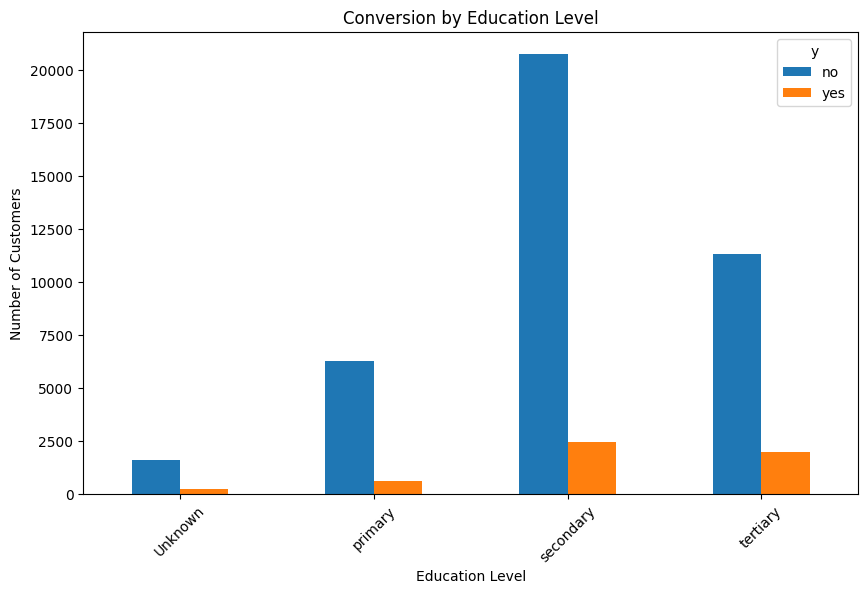

In [ ]:
education_conversion = (
    df.groupby(["education", "y"])
      .size()
      .unstack()
      .fillna(0)
)

education_conversion.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Conversion by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)

plt.show()

Conversion by Month

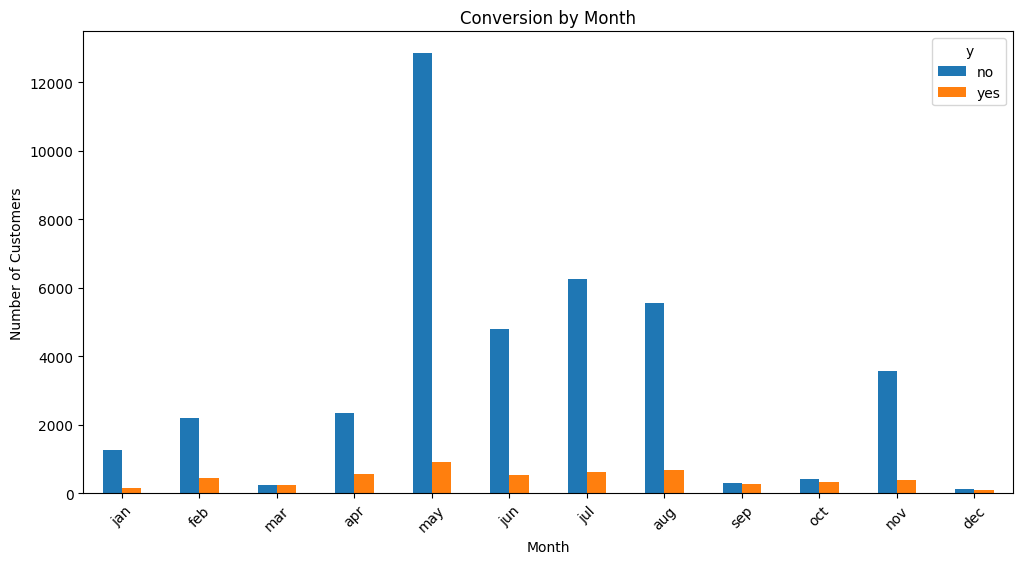

In [ ]:
month_conversion = (
    df.groupby(["month", "y"])
      .size()
      .unstack()
      .fillna(0)
)

# Order months chronologically
month_order = [
    "jan","feb","mar","apr","may","jun",
    "jul","aug","sep","oct","nov","dec"
]

month_conversion = month_conversion.reindex(month_order)

month_conversion.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Conversion by Month")
plt.xlabel("Month")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)

plt.show()

Conversion by Age Group

/tmp/ipykernel_1338/2272779912.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["AgeGroup", "y"])


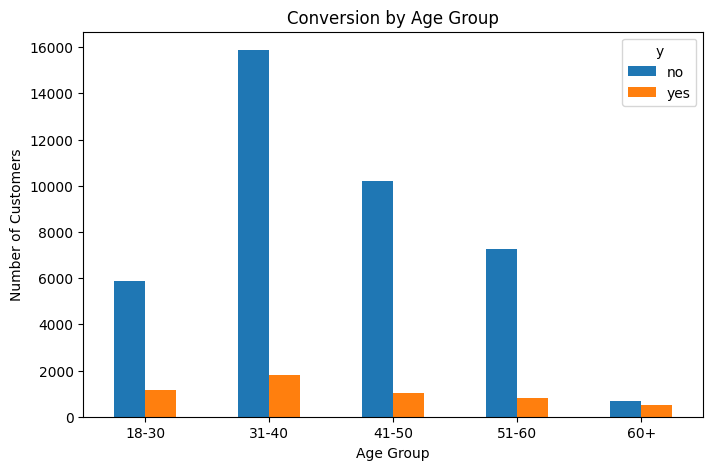

In [ ]:
age_conversion = (
    df.groupby(["AgeGroup", "y"])
      .size()
      .unstack()
      .fillna(0)
)

age_conversion.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Conversion by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.show()

# Conversion Analysis

Conversion Rate by Job

In [ ]:
job_rate = (
    df.groupby("job")["y"]
      .apply(lambda x: (x == "yes").mean() * 100)
      .sort_values(ascending=False)
)

print(job_rate)

job
student          28.678038
retired          22.791519
unemployed       15.502686
management       13.755551
admin.           12.202669
self-employed    11.842939
Unknown          11.805556
technician       11.056996
services          8.883004
housemaid         8.790323
entrepreneur      8.271688
blue-collar       7.274969
Name: y, dtype: float64


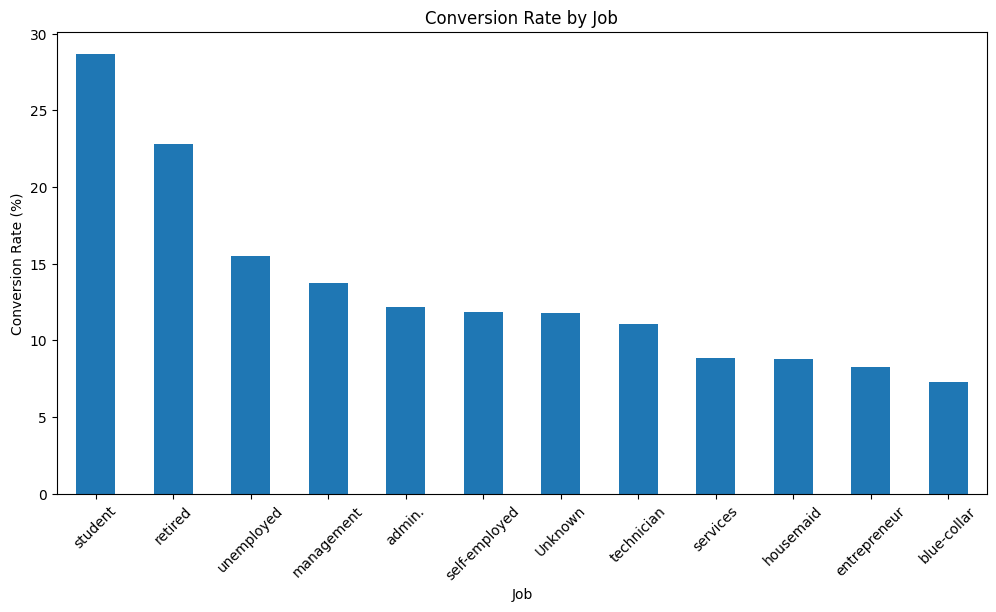

In [ ]:
job_rate.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Conversion Rate by Job")
plt.ylabel("Conversion Rate (%)")
plt.xlabel("Job")
plt.xticks(rotation=45)
plt.show()

Conversion Rate by Contact Method

contact
cellular     14.918900
telephone    13.420509
Unknown       4.070661
Name: y, dtype: float64


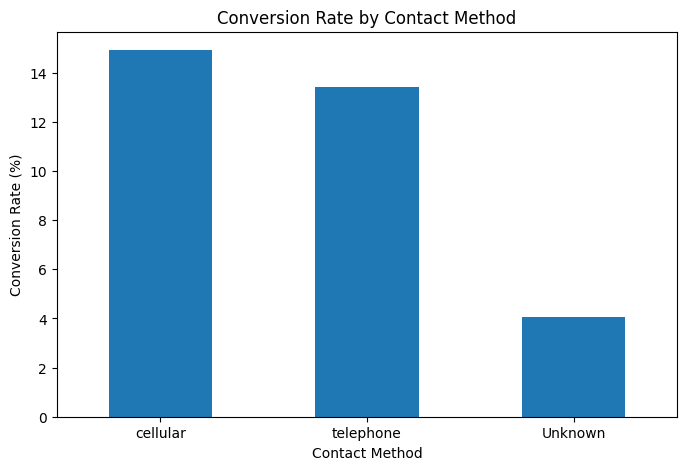

In [ ]:
contact_rate = (
    df.groupby("contact")["y"]
      .apply(lambda x: (x == "yes").mean() * 100)
      .sort_values(ascending=False)
)

print(contact_rate)

contact_rate.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Conversion Rate by Contact Method")
plt.ylabel("Conversion Rate (%)")
plt.xlabel("Contact Method")
plt.xticks(rotation=0)

plt.show()

Conversion Rate by Education Level

education
tertiary     15.006390
Unknown      13.570275
secondary    10.559435
primary       8.626478
Name: y, dtype: float64


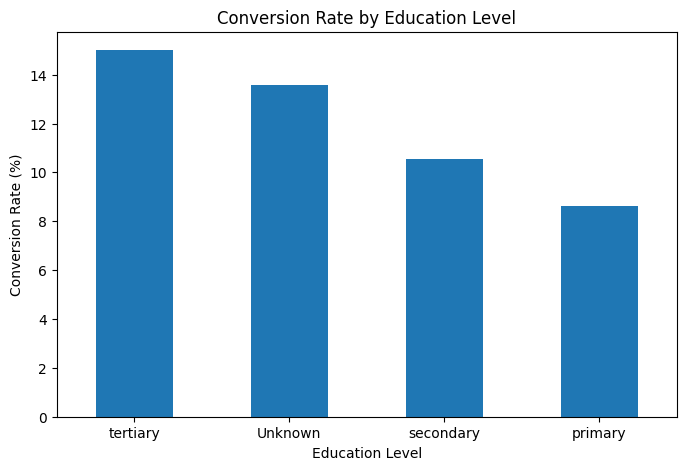

In [ ]:
education_rate = (
    df.groupby("education")["y"]
      .apply(lambda x: (x == "yes").mean() * 100)
      .sort_values(ascending=False)
)

print(education_rate)
education_rate.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Conversion Rate by Education Level")
plt.ylabel("Conversion Rate (%)")
plt.xlabel("Education Level")
plt.xticks(rotation=0)

plt.show()

Conversion Rate by Month

month
jan    10.121169
feb    16.647792
mar    51.991614
apr    19.679400
may     6.719454
jun    10.222805
jul     9.093546
aug    11.013286
sep    46.459413
oct    43.766938
nov    10.151134
dec    46.728972
Name: y, dtype: float64


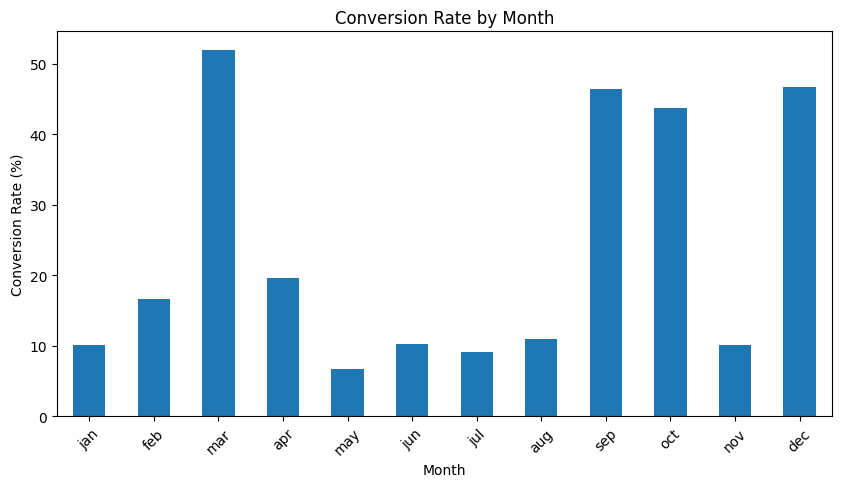

In [ ]:
month_rate = (
    df.groupby("month")["y"]
      .apply(lambda x: (x == "yes").mean() * 100)
)

# Arrange months chronologically
month_order = [
    "jan","feb","mar","apr","may","jun",
    "jul","aug","sep","oct","nov","dec"
]

month_rate = month_rate.reindex(month_order)

print(month_rate)

month_rate.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Conversion Rate by Month")
plt.ylabel("Conversion Rate (%)")
plt.xlabel("Month")
plt.xticks(rotation=45)

plt.show()

Conversion Rate by Age Group

/tmp/ipykernel_1338/1804485244.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("AgeGroup")["y"]


AgeGroup
18-30    16.215446
31-40    10.244813
41-50     9.066643
51-60    10.053304
60+      42.255892
Name: y, dtype: float64


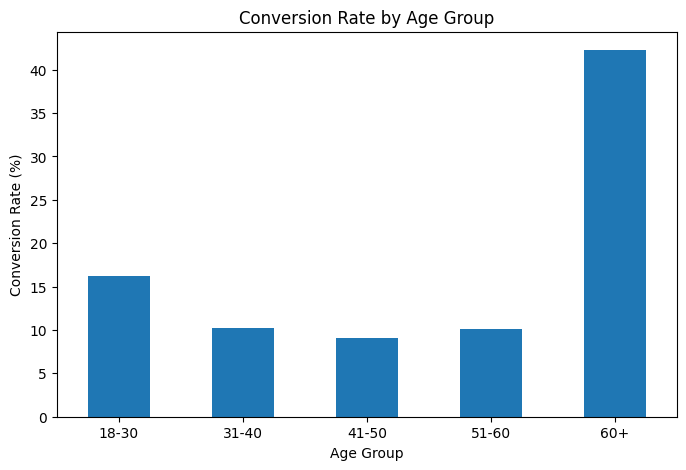

In [ ]:
age_rate = (
    df.groupby("AgeGroup")["y"]
      .apply(lambda x: (x == "yes").mean() * 100)
)

print(age_rate)

age_rate.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Conversion Rate by Age Group")
plt.ylabel("Conversion Rate (%)")
plt.xlabel("Age Group")
plt.xticks(rotation=0)

plt.show()